In [1]:
import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, BatchNormalization,
    Dropout, Flatten, Dense, LeakyReLU
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import AUC, Precision, Recall

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.utils import class_weight
import zipfile
import os
import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import drive
drive.mount('/content/drive')

zip_path = "/content/drive/MyDrive/Archive.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

Mounted at /content/drive


In [3]:
train_dir = "/content/dataset/train"
val_dir = "/content/dataset/val"
test_dir = "/content/dataset/test"

In [4]:
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.2,
    shear_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)
val_datagen  = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary')
val_data   = val_datagen.flow_from_directory(val_dir,   target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary')
test_data  = test_datagen.flow_from_directory(test_dir,  target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary', shuffle=False)

print("Class indices:", train_data.class_indices)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}


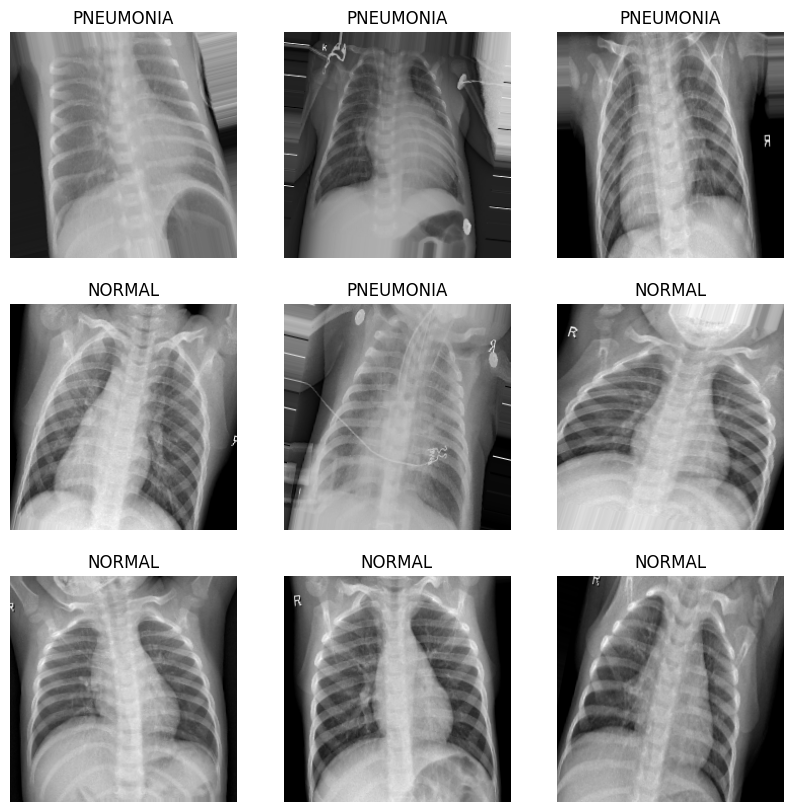

In [5]:
images, labels = next(train_data)
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.title("PNEUMONIA" if labels[i] == 1 else "NORMAL")
    plt.axis('off')
plt.show()

In [6]:
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_data.classes),
    y=train_data.classes
)
class_weights = dict(enumerate(class_weights))
print("Class weights:", class_weights)

Class weights: {0: np.float64(1.9448173005219984), 1: np.float64(0.6730322580645162)}


In [7]:
import tensorflow as tf
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
    print('GPU not found. Go to Runtime > Change Runtime Type > GPU')
else:
    print(f'GPU found: {device_name}')

GPU found: /device:GPU:0


In [8]:
LEAKY_ALPHA = 0.1

def build_model(input_shape=(224, 224, 3)):
    inputs = Input(shape=input_shape)

    # Conv Block 1
    x = Conv2D(32, (3, 3), padding="same", kernel_initializer="he_normal")(inputs)
    x = BatchNormalization()(x)
    x = LeakyReLU(negative_slope=LEAKY_ALPHA)(x)
    x = Conv2D(32, (3, 3), padding="same", kernel_initializer="he_normal")(x)
    x = BatchNormalization()(x)
    x = LeakyReLU(negative_slope=LEAKY_ALPHA)(x)
    x = MaxPooling2D((2, 2))(x)
    x = Dropout(0.25)(x)

    # Conv Block 2
    x = Conv2D(64, (3, 3), padding="same", kernel_initializer="he_normal")(x)
    x = BatchNormalization()(x)
    x = LeakyReLU(negative_slope=LEAKY_ALPHA)(x)
    x = Conv2D(64, (3, 3), padding="same", kernel_initializer="he_normal")(x)
    x = BatchNormalization()(x)
    x = LeakyReLU(negative_slope=LEAKY_ALPHA)(x)
    x = MaxPooling2D((2, 2))(x)
    x = Dropout(0.25)(x)

    # Conv Block 3
    x = Conv2D(128, (3, 3), padding="same", kernel_initializer="he_normal")(x)
    x = BatchNormalization()(x)
    x = LeakyReLU(negative_slope=LEAKY_ALPHA)(x)
    x = Conv2D(128, (3, 3), padding="same", kernel_initializer="he_normal")(x)
    x = BatchNormalization()(x)
    x = LeakyReLU(negative_slope=LEAKY_ALPHA)(x)
    x = MaxPooling2D((2, 2))(x)
    x = Dropout(0.25)(x)

    # Dense Layers
    x = Flatten()(x)
    x = Dense(512, kernel_initializer="he_normal")(x)
    x = LeakyReLU(negative_slope=LEAKY_ALPHA)(x)
    x = Dropout(0.5)(x)
    x = Dense(256, kernel_initializer="he_normal")(x)
    x = LeakyReLU(negative_slope=LEAKY_ALPHA)(x)
    x = Dropout(0.5)(x)
    x = Dense(128, kernel_initializer="he_normal")(x)
    x = LeakyReLU(negative_slope=LEAKY_ALPHA)(x)
    x = Dropout(0.4)(x)

    outputs = Dense(1, activation="sigmoid")(x)
    return Model(inputs=inputs, outputs=outputs, name="ChestXRay_CNN")

model = build_model()
model.summary()


Model: "ChestXRay_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 51,833,889 (197.73 MB)

 Trainable params: 51,832,993 (197.73 MB)

 Non-trainable params: 896 (3.50 KB)

In [9]:
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', AUC(name='auc'), Precision(name='precision'), Recall(name='recall')]
)

In [10]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint(filepath='best_chest_xray_model.keras', monitor='val_auc', save_best_only=True, mode='max', verbose=1)
]

In [11]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=4,
    callbacks=callbacks,
    class_weight=class_weights
)

Epoch 1/4
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 695ms/step - accuracy: 0.7222 - auc: 0.7261 - loss: 16.8311 - precision: 0.8762 - recall: 0.7365
Epoch 1: val_auc improved from None to 0.56250, saving model to best_chest_xray_model.keras

Epoch 1: finished saving model to best_chest_xray_model.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 155s 781ms/step - accuracy: 0.7686 - auc: 0.7940 - loss: 7.9434 - precision: 0.9001 - recall: 0.7745 - val_accuracy: 0.5000 - val_auc: 0.5625 - val_loss: 19.3763 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/4
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 686ms/step - accuracy: 0.8465 - auc: 0.9005 - loss: 1.6093 - precision: 0.9412 - recall: 0.8465
Epoch 2: val_auc did not improve from 0.56250
163/163 ━━━━━━━━━━━━━━━━━━━━ 113s 689ms/step - accuracy: 0.8401 - auc: 0.8990 - loss: 1.2999 - precision: 0.9376 - recall: 0.8408 - val_accuracy: 0.5000 - val_auc: 0.5391 - val_loss: 2.8590 - val_precision: 0.5000 - val_recall: 0.2500 - learning_rate: 0.

In [12]:
y_pred_probs = model.predict(test_data, verbose=1)
y_pred = (y_pred_probs >= 0.5).astype(int).flatten()
y_true = test_data.classes

print("─── Model Evaluation ───")
print(f"Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision : {precision_score(y_true, y_pred):.4f}")
print(f"Recall    : {recall_score(y_true, y_pred):.4f}")
print(f"F1-Score  : {f1_score(y_true, y_pred):.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 254ms/step
─── Model Evaluation ───
Accuracy  : 0.8462
Precision : 0.8952
Recall    : 0.8538
F1-Score  : 0.8740
